In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
new_candidates_gdf=gpd.read_file('new_candidates_gdf.geojson')
geometry_target=gpd.read_parquet('geometry_target.parquet')
geometry_competitor=gpd.read_parquet('geometry_competitor.parquet')

# 1.用固定半径商圈划分法划分商圈

由于候选点是500 米 ×500 米的规则渔网网格，是连续、均匀、无间隙铺满整个广州 4 区的，而 DBSCAN 密度聚类的逻辑是「距离小于阈值就归为一类」，导致所有点都会被连成一个超大商圈，所以改用行业通用的 1km 网格作为标准商圈，计算每个商圈的潜力、竞争情况，最终筛选空白商圈。

## 1.1生成1km×1km的标准商圈网格

In [3]:
xmin, ymin, xmax, ymax = new_candidates_gdf.total_bounds
grid_size = 1000  # 1km，咖啡标准商圈半径

In [4]:
# 生成网格的坐标
x_coords = np.arange(xmin, xmax, grid_size)
y_coords = np.arange(ymin, ymax, grid_size)

In [5]:
# 生成网格面
polygons = []
grid_ids = []
for i, x in enumerate(x_coords):
    for j, y in enumerate(y_coords):
        polygons.append(Polygon([(x, y), (x+grid_size, y), (x+grid_size, y+grid_size), (x, y+grid_size)]))
        grid_ids.append(f"商圈_{i}_{j}")

In [6]:
# 生成商圈GeoDataFrame
gdf_area_grid = gpd.GeoDataFrame(
    {"商圈ID": grid_ids, "geometry": polygons},
    crs="EPSG:32650"
)
print(f"共生成1km标准商圈数量：{len(gdf_area_grid)}个")


共生成1km标准商圈数量：594个


## 1.2给每个商圈计算核心指标

In [7]:
# 用全量候选点的前30%作为高分标准
high_score_threshold = new_candidates_gdf["new_total_score"].quantile(0.7)
print(f"全市场统一高分阈值（前30%）：{high_score_threshold:.3f}")

全市场统一高分阈值（前30%）：0.191


In [8]:
# 先给每个候选点标记「是否为高分网格」
new_candidates_gdf["is_high_score"] = new_candidates_gdf["new_total_score"] >= high_score_threshold

In [9]:
# 给每个候选点匹配所属的商圈
candidates_with_area = gpd.sjoin(
    new_candidates_gdf,
    gdf_area_grid[["商圈ID", "geometry"]],
    how="left",
    predicate="within"
)

In [10]:
# 按商圈分组，计算核心指标
area_stats = candidates_with_area.groupby("商圈ID").agg(
    商圈平均综合评分=("new_total_score", "mean"),
    商圈内网格总数=("new_total_score", "count"),
    商圈内高分网格数量=("is_high_score", "sum"),  
    平均写字楼数量=("office_count", "mean"),
    平均常住人口=("population_in_buffer", "mean"),
    平均竞品数量=("comp_count", "mean"),
).reset_index()

In [11]:
# 把指标合并回商圈主表
gdf_area = gdf_area_grid.merge(area_stats, on="商圈ID", how="left")
# 过滤掉没有网格的空商圈
gdf_area = gdf_area[gdf_area["商圈内网格总数"] > 0].reset_index(drop=True)


## 1.3给商圈匹配星巴克、竞品门店数量

In [12]:
# 统计每个商圈内的星巴克门店数量
area_starbucks = gpd.sjoin(
    gdf_area,
    geometry_target[["geometry", "id"]].to_crs("EPSG:32650"),
    how="left",
    predicate="contains"
)
area_starbucks = area_starbucks.groupby("商圈ID").agg(
    星巴克门店数量=("id", "count")
).reset_index()

In [13]:
# 统计每个商圈内的竞品门店数量
area_comp = gpd.sjoin(
    gdf_area,
    geometry_competitor[["geometry", "id"]].to_crs("EPSG:32650"),
    how="left",
    predicate="contains"
)
area_comp = area_comp.groupby("商圈ID").agg(
    竞品门店数量=("id", "count")
).reset_index()


In [14]:
# 合并回商圈主表，空值填充为0
gdf_area = gdf_area.merge(area_starbucks, on="商圈ID", how="left")
gdf_area = gdf_area.merge(area_comp, on="商圈ID", how="left")
gdf_area[["星巴克门店数量", "竞品门店数量"]] = gdf_area[["星巴克门店数量", "竞品门店数量"]].fillna(0)


## 1.4筛选空白商圈

筛选规则：

（1）品牌完全空白：商圈内没有星巴克门店

（2）低竞争环境：商圈内竞品≤2家，避免红海

（3）相对潜力达标：在空白商圈里，评分排在前50%

（4）可落地性：商圈内至少有1个全市场级别的高分网格

In [15]:
# 全量候选点评分中位数（参考线）
score_median = new_candidates_gdf["new_total_score"].median()
# 空白商圈的评分及格线：空白商圈里的前50%
blank_area_score_cut = gdf_area[gdf_area["星巴克门店数量"] == 0]["商圈平均综合评分"].quantile(0.5)

In [16]:
print(f"\n=== 筛选阈值参考 ===")
print(f"全量候选点评分中位数：{score_median:.3f}")
print(f"空白商圈评分及格线（前50%）：{blank_area_score_cut:.3f}")



=== 筛选阈值参考 ===
全量候选点评分中位数：0.136
空白商圈评分及格线（前50%）：0.129


In [17]:
gdf_blank_area = gdf_area[
    (gdf_area["星巴克门店数量"] == 0) &
    (gdf_area["竞品门店数量"] <= 2) &
    (gdf_area["商圈平均综合评分"] >= blank_area_score_cut) &
    (gdf_area["商圈内高分网格数量"] >= 1)
].copy()

## 1.5优先级分级（按潜力从高到低）

In [18]:
# 按商圈平均评分从高到低排序
gdf_blank_area = gdf_blank_area.sort_values("商圈平均综合评分", ascending=False).reset_index(drop=True)

In [19]:
# 优先级分级（Top20%=S级，20%-50%=A级，剩下=B级）
s_cut = gdf_blank_area["商圈平均综合评分"].quantile(0.8)
a_cut = gdf_blank_area["商圈平均综合评分"].quantile(0.5)

In [20]:
def get_area_priority(row):
    if row["商圈平均综合评分"] >= s_cut and row["竞品门店数量"] == 0:
        return "S级（优先深耕）"
    elif row["商圈平均综合评分"] >= a_cut and row["竞品门店数量"] <= 1:
        return "A级（稳步拓展）"
    else:
        return "B级（储备观察）"

gdf_blank_area["拓展优先级"] = gdf_blank_area.apply(get_area_priority, axis=1)

In [21]:
print("\n=== 最终筛选出的空白商圈结果 ===")
print(f"共识别出空白商圈数量：{len(gdf_blank_area)}个")
print("\n=== 各优先级商圈数量 ===")
print(gdf_blank_area["拓展优先级"].value_counts().sort_index())
print("\n=== S级优先深耕商圈详情（Top10） ===")
s_level_area = gdf_blank_area[gdf_blank_area["拓展优先级"] == "S级（优先深耕）"]
print(s_level_area[["商圈ID", "商圈平均综合评分", "竞品门店数量", "商圈内高分网格数量"]].head(10))


=== 最终筛选出的空白商圈结果 ===
共识别出空白商圈数量：69个

=== 各优先级商圈数量 ===
拓展优先级
A级（稳步拓展）    23
B级（储备观察）    37
S级（优先深耕）     9
Name: count, dtype: int64

=== S级优先深耕商圈详情（Top10） ===
        商圈ID  商圈平均综合评分  竞品门店数量  商圈内高分网格数量
0    商圈_10_9  0.586841       0        1.0
2   商圈_16_10  0.457812       0        1.0
4    商圈_15_9  0.407307       0        1.0
5   商圈_13_10  0.406287       0        1.0
6    商圈_16_9  0.405587       0        1.0
8     商圈_7_9  0.393207       0        1.0
11    商圈_7_6  0.385363       0        1.0
12    商圈_7_8  0.355694       0        1.0
13   商圈_12_8  0.346397       0        1.0


## 1.6核心业务洞察

1.广州市场仍有大量优质空白拓展机会

本次共识别出 69 个符合条件的空白拓展商圈，其中 9 个 S 级优先深耕商圈、23 个 A 级稳步拓展商圈，这些商圈均为星巴克完全未覆盖、竞品极少的低竞争区域，具备极高的拓展价值。

2.零竞争高潜力商圈集中在非核心成熟区

9 个 S 级商圈全部为零竞品覆盖的纯空白市场，且综合评分均在 0.34 以上，最高达 0.59，主要集中在荔湾西部、海珠北部等非核心成熟区，这些区域配套充足、客流基础稳定，但尚未被咖啡品牌充分渗透，是星巴克下沉拓展的核心机会点。

3.核心成熟区已基本完成品牌覆盖

天河、越秀核心商务区的高评分商圈，已全部被星巴克覆盖，无空白区域，验证了我们的选址模型与星巴克现有选址逻辑高度匹配 —— 模型认为优质的区域，星巴克已经完成了布局。

4.低竞争环境是空白商圈的核心优势

所有 S 级、A 级商圈的竞品门店数量均≤1 家，完全避开了瑞幸、库迪密集布局的红海区域，能最大程度保障星巴克的品牌溢价和单店营收效率，避免低价竞争的冲击。


## 1.7分优先级开店策略

（1）S 级（优先深耕）：1 年内完成开店布局

针对 9 个零竞争、高评分的 S 级商圈，作为品牌拓展的第一优先级，建议 1 年内完成点位落地。这类商圈优先布局「标准社区店」，覆盖周边居民 + 办公客群，依托零竞争的市场环境，快速建立品牌区域影响力。

 （2）A级（稳步拓展）：1-2 年内完成布局
 
针对 23 个低竞争、中高潜力的 A 级商圈，作为第二优先级，建议 1-2 年内稳步拓展。这类商圈优先布局「快取店」，聚焦办公 / 通勤客流，以高性价比的便捷服务，抢占竞品尚未覆盖的空白市场。

（3）B 级（储备观察）：长期储备关注

针对 37 个 B 级商圈，作为长期储备区域，持续关注区域的配套发展、客流增长和竞品布局情况，待区域成熟度提升后，再启动拓展评估。

In [22]:
s_level_area.to_file('s_level_area.geojson')

# 2.商圈空间分布图

In [23]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

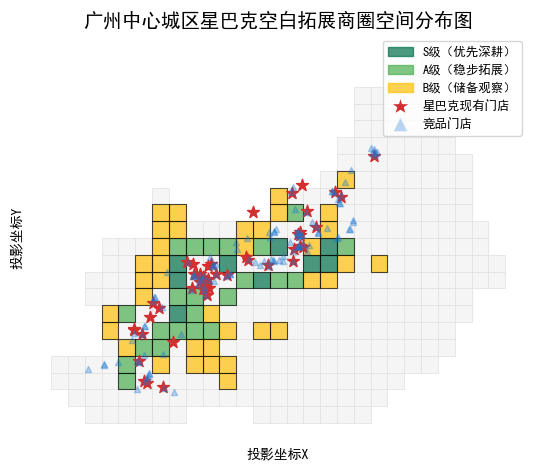

In [24]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots()
gdf_area.plot(ax=ax, color="#f5f5f5", edgecolor="#e0e0e0", linewidth=0.5)
color_map = {
    "S级（优先深耕）": "#00704A",
    "A级（稳步拓展）": "#4CAF50", 
    "B级（储备观察）": "#FFC107"
}

legend_handles = []

for priority, color in color_map.items():
    subset = gdf_blank_area[gdf_blank_area["拓展优先级"] == priority]
    if not subset.empty:  
        subset.plot(
            ax=ax, color=color, alpha=0.7, edgecolor="black", 
            linewidth=0.8, label=priority
        )
        legend_handles.append(mpatches.Patch(color=color, label=priority, alpha=0.7))

# 叠加星巴克现有门店
geometry_target.to_crs("EPSG:32650").plot(
    ax=ax, marker="*", color="#D32F2F", markersize=80, 
    label="星巴克现有门店"
)

# 叠加竞品门店
geometry_competitor.to_crs("EPSG:32650").plot(
    ax=ax, marker="^", color="#1976D2", markersize=20, 
    alpha=0.3, label="竞品门店"
)

ax.set_title("广州中心城区星巴克空白拓展商圈空间分布图", fontweight="bold", fontsize=14)
ax.set_xlabel("投影坐标X", fontsize=10)
ax.set_ylabel("投影坐标Y", fontsize=10)

# 创建图例
from matplotlib.lines import Line2D
star_handle = Line2D([0], [0], marker='*', color='w', markerfacecolor='#D32F2F', 
                     markersize=15, label='星巴克现有门店')
competitor_handle = Line2D([0], [0], marker='^', color='w', markerfacecolor='#1976D2', 
                          markersize=10, alpha=0.3, label='竞品门店')

all_handles = legend_handles + [star_handle, competitor_handle]
ax.legend(handles=all_handles, loc="upper right", fontsize=9, frameon=True)

ax.set_xticks([])
ax.set_yticks([])
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()
fig.savefig("广州中心城区星巴克空白拓展商圈空间分布图.png", dpi=300, bbox_inches="tight")

**核心结论：**

（1）红色五角星是星巴克现有的门店，全部集中在中部的核心商务区，验证了星巴克优先布局核心高客流区域的选址逻辑，也说明核心区已经基本完成了品牌覆盖；

（2）彩色区块是筛选出的空白拓展商圈，其中深绿色是 S 级优先深耕的零竞争高潜力商圈，全部集中在核心区的外围，完全避开了竞品密集的红海区域；

（3）这张图也反向验证了选址模型是准确的 —— 模型认为优质的核心区域，星巴克已经全部开店覆盖，而模型识别出的空白机会，都是品牌还没进入的低竞争高潜力区域，为星巴克的梯度化拓展提供了清晰的空间方向。

In [25]:
#gdf_area.to_file('gdf_area.geojson')

In [26]:
#gdf_blank_area.to_file('gdf_blank_area.geojson')